# Exploratory Data Analysis (EDA) for online Casino Gaming Revenue
## Prepared by: Phiona Namugga, Data Scientist
## Date: April 03, 2025

## 1. Introduction

### 1.1 Project Overview
The online gaming industry is rapidly grow globally. Understanding the financial metrics and performance of casino operations is critical to stakeholders seeking to comply with regulations,optimize revenue, and maintain competitive advantage. This Exploratory Data Analysis focuses on a dataset of monthly performance reports from online casino gaming licensees operating in Connecticut, a state that legalized online gaming in October 2021. Commissioned by a consortium of online casino operators through our consulting firm, this analysis aims to dissect key financial metrics, uncover actionable trends, and provide strategic insights to enhance business decision-making. As a data scientist I have been tasked with leveraging this dataset to deliver a comprehensive evaluation of promotional impacts, revenue patterns, and licensee performance, ultimately supporting the consortium’s goals of profitability and operational efficiency.

The dataset spans from October 2021 to November 2024, covering the initial rollout of online casino gaming in Connecticut and its subsequent growth. It includes detailed records from four licensees: Mohegan Tribe On-Reservation, MPTN On-Reservation, MPI Master Wagering License CT, LLC, and Mohegan Digital, LLC. These entities represent a mix of tribal and commercial operators, each navigating unique regulatory and market dynamics. By analyzing this data, we aim to address the consortium’s concerns about revenue fluctuations, assess the effectiveness of promotional strategies, and benchmark performance across licensees.

### 1.2 Significance of the Analysis
The online casino gaming sector in Connecticut operates under a tightly regulated framework, with revenue streams influenced by factors such as patron wagering behavior, promotional incentives, and state-mandated payment obligations. Since its inception on October 12, 2021, the industry has seen rapid adoption, but operators have noted inconsistent revenue trends that require deeper investigation. This EDA is timely and relevant, as it coincides with evolving regulatory changes—such as the phased reduction of promotional deduction limits from 25% to 15%—and operational milestones, including the staggered entry of tribal licensees (MPTN in December 2021 and Mohegan Tribe in May 2022). Additionally, a reported data latency issue in May 2024 by Mohegan Digital, LLC underscores the need for robust data analysis to ensure accuracy and reliability in financial reporting.

For the consortium, this analysis offers a data-driven lens to understand these dynamics, identify growth opportunities, and mitigate risks. Insights derived here will inform strategic decisions, such as adjusting promotional budgets, optimizing seasonal operations, and addressing underperformance among specific licensees. Beyond immediate business needs, the findings will also support regulatory compliance by aligning with payment schedules (due the 15th of each following month) and tax obligations (18% of Gross Gaming Revenue until September 2026, then 20%).

### Objectives
1. Analyze trends in gaming revenue over time and across licensees.
2. Identify key performance metrics (e.g., net winnings, gross revenue).
3. Discover correlations between variables (e.g., promotions and revenue).
4. Handle missing values and outliers for robust analysis.
5. Deliver actionable insights for business and regulatory decisions.

### 1.4 Dataset Context
The dataset is a CSV file containing monthly financial reports from online casino gaming operations in Connecticut. It captures the following columns:
- **Licensee**: The entity holding the gaming license (e.g., Mohegan Digital, LLC).
- **Fiscal Year**: The fiscal year of the report (e.g., 2021/22, 2022/23).
- **Month Ending**: The last day of the reporting month (e.g., 06/30/2022).
- **Wagers**: Total amount wagered by patrons.
- **Patron Winnings**: Total amount paid out to patrons.
- **Cancelled Wagers**: Wagers voided or cancelled.
- **Online Casino Gaming Win/(Loss)**: Net revenue from gaming (Wagers - Patron Winnings - Cancelled Wagers).
- **Promotional Coupons or Credits Wagered**: Amount wagered using promotional incentives.
- **Promotional Deduction**: Amount deducted from Win/(Loss) based on regulatory limits.
- **Total Gross Gaming Revenue (GGR)**: Final revenue after deductions (Win/(Loss) - Promotional Deduction).
- **Payment**: Amount paid to the state (18% of GGR, or $0 if negative).

#### Key Notes
1. **Payment Schedule**: Monthly payments are due to the state by the 15th of the following month.
2. **Start Date**: Online casino gaming began on October 12, 2021.
3. **Promotional Rules**: Deductions are limited to the lesser of a percentage of Win/(Loss) (25% from Oct 2021-Sep 2022, 20% from Oct 2022-Sep 2023, 15% thereafter) or actual promotional coupons wagered.
4. **Payment Rate**: 18% of GGR until September 2026, increasing to 20% thereafter; negative payments are set to $0.
5. **Licensee Milestones**: MPTN began operations on December 7, 2021; Mohegan Tribe on May 6, 2022.
6. **Data Correction**: Mohegan Digital, LLC amended its May 2024 return due to latency issues, reducing Wagers and Win/(Loss) by $679 and Payment by $104.

### 1.5 Approach
This EDA will proceed through data preprocessing, statistical analysis, and visualization, culminating in business-focused insights. We will use Python libraries (e.g., pandas, matplotlib, seaborn) to process the data and generate interpretable outputs. The analysis will address the consortium’s problem statements—revenue trends, promotional impacts, performance comparisons, and wagering patterns—through a structured set of business questions, ensuring alignment with their strategic priorities.

By the end of this report, the consortium will have a clear understanding of their operational performance, the drivers of revenue fluctuations, and actionable steps to enhance their business outcomes in Connecticut’s online gaming market.

### Importing libraries

In [1]:
# Installing libraries for the exploratory data analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from datetime import datetime

### Data Preprocessing
Description: Load, inspect, and clean the dataset to ensure data quality for analysis.

### Data loading/collection

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Phionanamugga/EDA_Tax_returns/refs/heads/feature1/Casino_Tax_data.csv')

#### Data inspection
- Checking data types, missing values, and duplicates.
- Displaying the first few rows and summary info.

In [4]:
# Setting the plotting style
sns.set(style="whitegrid")

In [5]:
df.head()

,Fiscal Year,Month Ending,Licensee,Wagers,Patron Winnings,Cancelled Wagers,Online Casino Gaming Win/(Loss),Promotional Coupons or Credits Wagered (3),Promotional Deduction (4),Total Gross Gaming Revenue,Payment (5)
0,2021/22,06/30/2022 12:00:00 AM,Mohegan Tribe On-Reservation,379023,335505,5,43513,6390,6390,37123,6682
1,2021/22,06/30/2022 12:00:00 AM,MPTN On-Reservation,671843,685886,3,-14046,29041,0,-14046,0
2,2021/22,06/30/2022 12:00:00 AM,"MPI Master Wagering License CT, LLC",420056291,406814933,164727,13076631,12372142,3269158,9807473,1765345
3,2021/22,06/30/2022 12:00:00 AM,"Mohegan Digital, LLC",254393582,246515856,11645,7866081,1397441,1397441,6468640,1164355
4,2021/22,05/31/2022 12:00:00 AM,Mohegan Tribe On-Reservation,716607,681306,0,35301,4130,4130,31171,5611


In [6]:
df.describe()

,Wagers,Patron Winnings,Cancelled Wagers,Online Casino Gaming Win/(Loss),Promotional Coupons or Credits Wagered (3),Promotional Deduction (4),Total Gross Gaming Revenue,Payment (5)
count,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02
mean,2.742207e+08,2.655218e+08,1.783408e+05,8.520509e+06,2.909760e+06,1.470359e+06,7.050150e+06,1.269229e+06
std,2.815530e+08,2.725166e+08,2.826004e+05,8.921912e+06,5.194974e+06,1.512958e+06,7.483596e+06,1.346855e+06
min,1.145280e+05,1.113650e+05,0.000000e+00,-8.099000e+04,0.000000e+00,0.000000e+00,-8.099000e+04,0.000000e+00
25%,1.407190e+06,1.357855e+06,5.000000e+00,3.713950e+04,1.118100e+04,6.188500e+03,3.172700e+04,5.711000e+03
50%,2.656540e+08,2.575127e+08,3.887000e+03,7.866081e+06,1.065100e+06,1.021521e+06,6.821088e+06,1.227796e+06
75%,5.352846e+08,5.156584e+08,2.913700e+05,1.587461e+07,3.844558e+06,3.071548e+06,1.304302e+07,2.347743e+06
max,7.838842e+08,7.573176e+08,1.133136e+06,2.570443e+07,3.220656e+07,4.163625e+06,2.281557e+07,4.106803e+06


### 2.3 Handling Missing Values
- Identifying and imputing or remove missing values (e.g., using median for numeric columns).
- Justifying the approach based on data context.

In [7]:
# Checking for all missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Fiscal Year                                 143 non-null    object
 1   Month Ending                                143 non-null    object
 2   Licensee                                    143 non-null    object
 3   Wagers                                      143 non-null    int64 
 4   Patron Winnings                             143 non-null    int64 
 5   Cancelled Wagers                            143 non-null    int64 
 6   Online Casino Gaming Win/(Loss)             143 non-null    int64 
 7   Promotional Coupons or Credits Wagered (3)  143 non-null    int64 
 8   Promotional Deduction (4)                   143 non-null    int64 
 9   Total Gross Gaming Revenue                  143 non-null    int64 
 10  Payment (5)               

In [8]:
# checking for the sum of missing values in each column
df.isnull().sum()

Fiscal Year                                   0
Month Ending                                  0
Licensee                                      0
Wagers                                        0
Patron Winnings                               0
Cancelled Wagers                              0
Online Casino Gaming Win/(Loss)               0
Promotional Coupons or Credits Wagered (3)    0
Promotional Deduction (4)                     0
Total Gross Gaming Revenue                    0
Payment (5)                                   0
dtype: int64

array([[<Axes: title={'center': 'Wagers'}>,
        <Axes: title={'center': 'Patron Winnings'}>,
        <Axes: title={'center': 'Cancelled Wagers'}>],
       [<Axes: title={'center': 'Online Casino Gaming Win/(Loss)'}>,
        <Axes: title={'center': 'Promotional Coupons or Credits Wagered (3)'}>,
        <Axes: title={'center': 'Promotional Deduction (4)'}>],
       [<Axes: title={'center': 'Total Gross Gaming Revenue'}>,
        <Axes: title={'center': 'Payment (5)'}>, <Axes: >]], dtype=object)

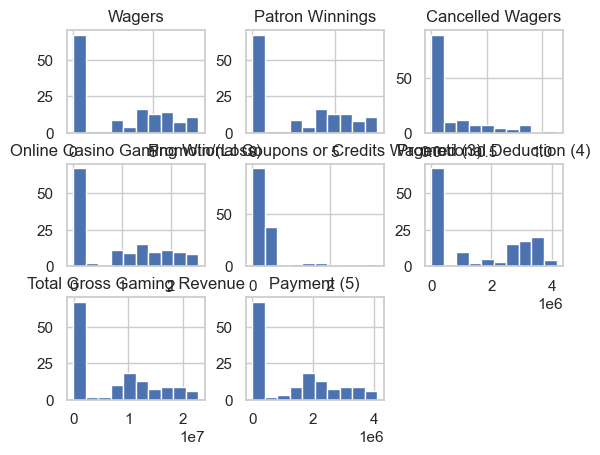

In [9]:
# visualizing existing columns using histograms
df.hist()

### 2.4 Handling Outliers
- Using boxplots to detect outliers in key columns (e.g.,Fiscal year,Month ending, Wagers, GGR).
- Deciding whether to cap, transform, or retain outliers based on business relevance.

In [4]:
# Defining key columns for outlier detection
key_columns = [
    'Wagers',
    'Total Gross Gaming Revenue',
    'Promotional Coupons or Credits Wagered (3)',
    'Payment (5)',
    'Fiscal Year',
    'Month Ending',
    'Licensee',
    'Promotional Coupons or Credits Wagered (3)',
    'Promotional Deduction (4)',   
]

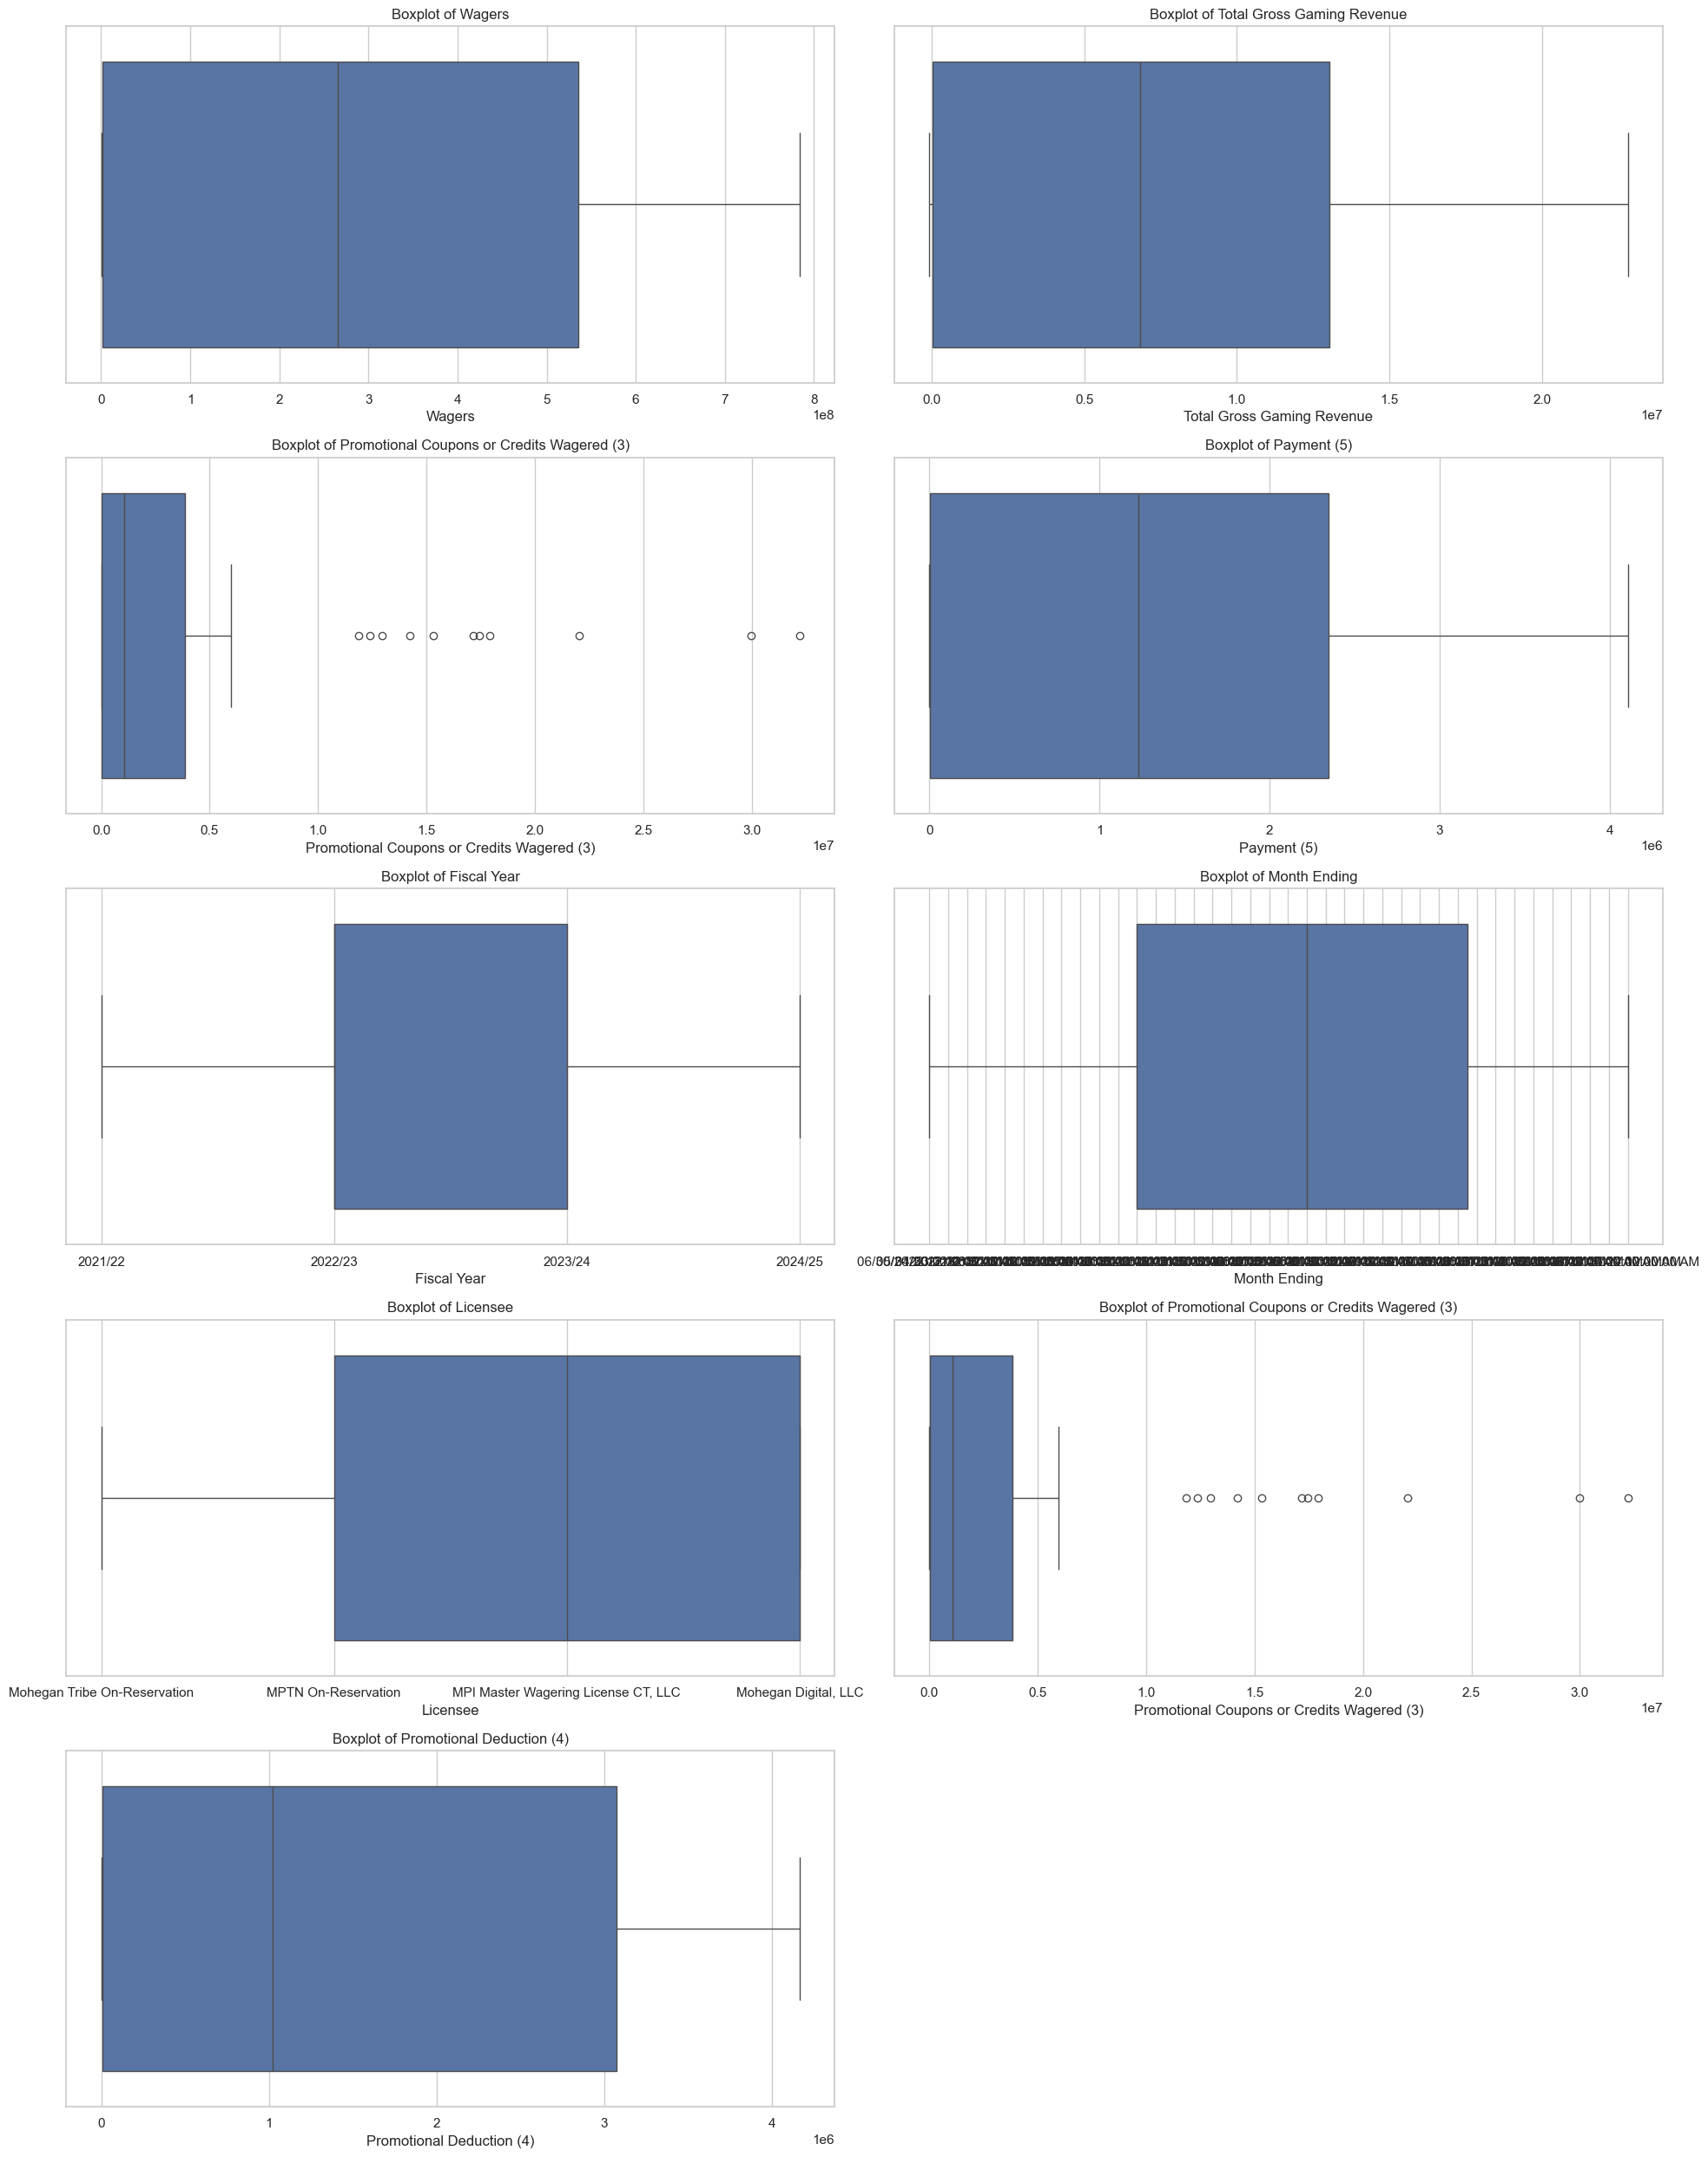

In [11]:
# Visualizing outliers using boxplots
num_cols = len(key_columns)
num_rows = (num_cols + 1) // 2  #Calculating number of rows needed for Subplots
plt.figure(figsize=(20, num_rows * 5))  #Adjusting figure height dynamically

for i, col in enumerate(key_columns, 1):
    plt.subplot(num_rows, 2, i)  # Creating the grid with num_rows x 2 subplots
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [142]:
# Detecting outliers using IQR method
Outliers_dict = {}
for col in key_columns:
    # Ensuring that the column is numeric
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

In [143]:
# Ensuring the column is numeric
df[col] = pd.to_numeric(df[col], errors='coerce')

# Identifying outliers
Outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
Outliers_dict[col] = {
    'lower_bound': lower_bound,
    'upper_bound': upper_bound,
    'outliers': Outliers,
    'outlier_count': len(Outliers)
}
print(f"\nOutliers in {col}:")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Number of Outliers: {Outliers_dict[col]['outlier_count']}")
if not Outliers.empty:
    print(Outliers)


Outliers in Promotional Deduction (4):
Lower Bound: -4591851.50, Upper Bound: 7669588.50
Number of Outliers: 0


In [15]:
# Ensure 'Month Ending' is in datetime format
df['Month Ending'] = pd.to_datetime(df['Month Ending'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

### 3. Exploratory Data Analysis (EDA)
Description: Perform a comprehensive analysis using descriptive statistics and visualizations to address the problem statements.

### 3.1 Descriptive Statistics
Calculating summary statistics for key metrics to understand their distributions.

In [ ]:
# Filter for unique numeric columns
numeric_columns = [col for col in key_columns if pd.api.types.is_numeric_dtype(df[col])]

#Calculate overall descriptive statistics
overall_stats = df[numeric_columns].describe().T
# Add standard deviation explicitly (already in describe, but for clarity)
overall_stats['std'] = df[numeric_columns].std()
# Reorder and rename columns for clarity
overall_stats = overall_stats[['mean', '50%', 'std', 'min', '25%', '75%', 'max']]
overall_stats.columns = ['Mean', 'Median', 'Std Dev', 'Min', '25th Percentile', '75th Percentile', 'Max']

# Format the table for readability (convert to millions where applicable)
overall_stats_formatted = overall_stats.copy()
for col in overall_stats_formatted.columns:
    overall_stats_formatted[col] = overall_stats_formatted[col].apply(
        lambda x: f"${x/1e6:.2f}M" if abs(x) >= 1e6 else f"${x:.2f}"
    )

print("\nOverall Descriptive Statistics:")
print("------------------------------")
print(overall_stats_formatted)

# Calculate licensee-specific descriptive statistics
licensees = df['Licensee'].unique()
licensee_stats = {}
for licensee in licensees:
    licensee_data = df[df['Licensee'] == licensee][numeric_columns]
    stats = licensee_data.describe().T
    stats['std'] = licensee_data.std()
    stats = stats[['mean', '50%', 'std', 'min', '25%', '75%', 'max']]
    stats.columns = ['Mean', 'Median', 'Std Dev', 'Min', '25th Percentile', '75th Percentile', 'Max']
    licensee_stats[licensee] = stats

# Combine licensee-specific stats into a single DataFrame for comparison
licensee_stats_combined = pd.concat(
    [stats.assign(Licensee=licensee) for licensee, stats in licensee_stats.items()]
)
licensee_stats_combined = licensee_stats_combined.reset_index().rename(columns={'index': 'Metric'})
licensee_stats_combined = licensee_stats_combined[['Licensee', 'Metric', 'Mean', 'Median', 'Std Dev', 'Min', '25th Percentile', '75th Percentile', 'Max']]

# Format the table for readability
licensee_stats_formatted = licensee_stats_combined.copy()
for col in ['Mean', 'Median', 'Std Dev', 'Min', '25th Percentile', '75th Percentile', 'Max']:
    licensee_stats_formatted[col] = licensee_stats_formatted[col].apply(
        lambda x: f"${x/1e6:.2f}M" if abs(x) >= 1e6 else f"${x:.2f}"
    )

print("\nLicensee-Specific Descriptive Statistics:")
print("----------------------------------------")
print(licensee_stats_formatted)


Overall Descriptive Statistics:
------------------------------
                                                Mean    Median   Std Dev  \
Wagers                                      $274.22M  $265.65M  $281.55M   
Total Gross Gaming Revenue                    $7.05M    $6.82M    $7.48M   
Promotional Coupons or Credits Wagered (3)    $2.91M    $1.07M    $5.19M   
Payment (5)                                   $1.27M    $1.23M    $1.35M   
Fiscal Year                                     $nan      $nan      $nan   
Month Ending                                    $nan      $nan      $nan   
Licensee                                        $nan      $nan      $nan   
Promotional Coupons or Credits Wagered (3)    $2.91M    $1.07M    $5.19M   
Promotional Deduction (4)                     $1.47M    $1.02M    $1.51M   

                                                   Min 25th Percentile  \
Wagers                                      $114528.00          $1.41M   
Total Gross Gaming Revenue 

In [145]:
# Skewness and kurtosis for key metrics
print("\nSkewness and Kurtosis for Key Metrics")
skewness = df[key_columns].skew().round(2)
kurtosis = df[key_columns].kurtosis().round(2)
print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)


Skewness and Kurtosis for Key Metrics
Skewness:
 Wagers                                        0.32
Total Gross Gaming Revenue                    0.49
Promotional Coupons or Credits Wagered (3)    3.35
Payment (5)                                   0.49
Fiscal Year                                    NaN
Month Ending                                   NaN
Licensee                                       NaN
Promotional Coupons or Credits Wagered (3)    3.35
Promotional Deduction (4)                     0.26
dtype: float64

Kurtosis:
 Wagers                                        -1.51
Total Gross Gaming Revenue                    -1.21
Promotional Coupons or Credits Wagered (3)    13.21
Payment (5)                                   -1.21
Fiscal Year                                     NaN
Month Ending                                    NaN
Licensee                                        NaN
Promotional Coupons or Credits Wagered (3)    13.21
Promotional Deduction (4)                     -1

### Visualizations
Using plots to explore trends, relationships, and comparisons.

#### Plot Histograms for Revenue Distribution
Histograms for key revenue-related columns: `Total Gross Gaming Revenue (GGR)`, `Wagers`, and `Payment`.

/Users/phionanamugga/Documents/coding/datascience/EDA_Tax_returns/.venv/lib/python3.9/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/phionanamugga/Documents/coding/datascience/EDA_Tax_returns/.venv/lib/python3.9/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/phionanamugga/Documents/coding/datascience/EDA_Tax_returns/.venv/lib/python3.9/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


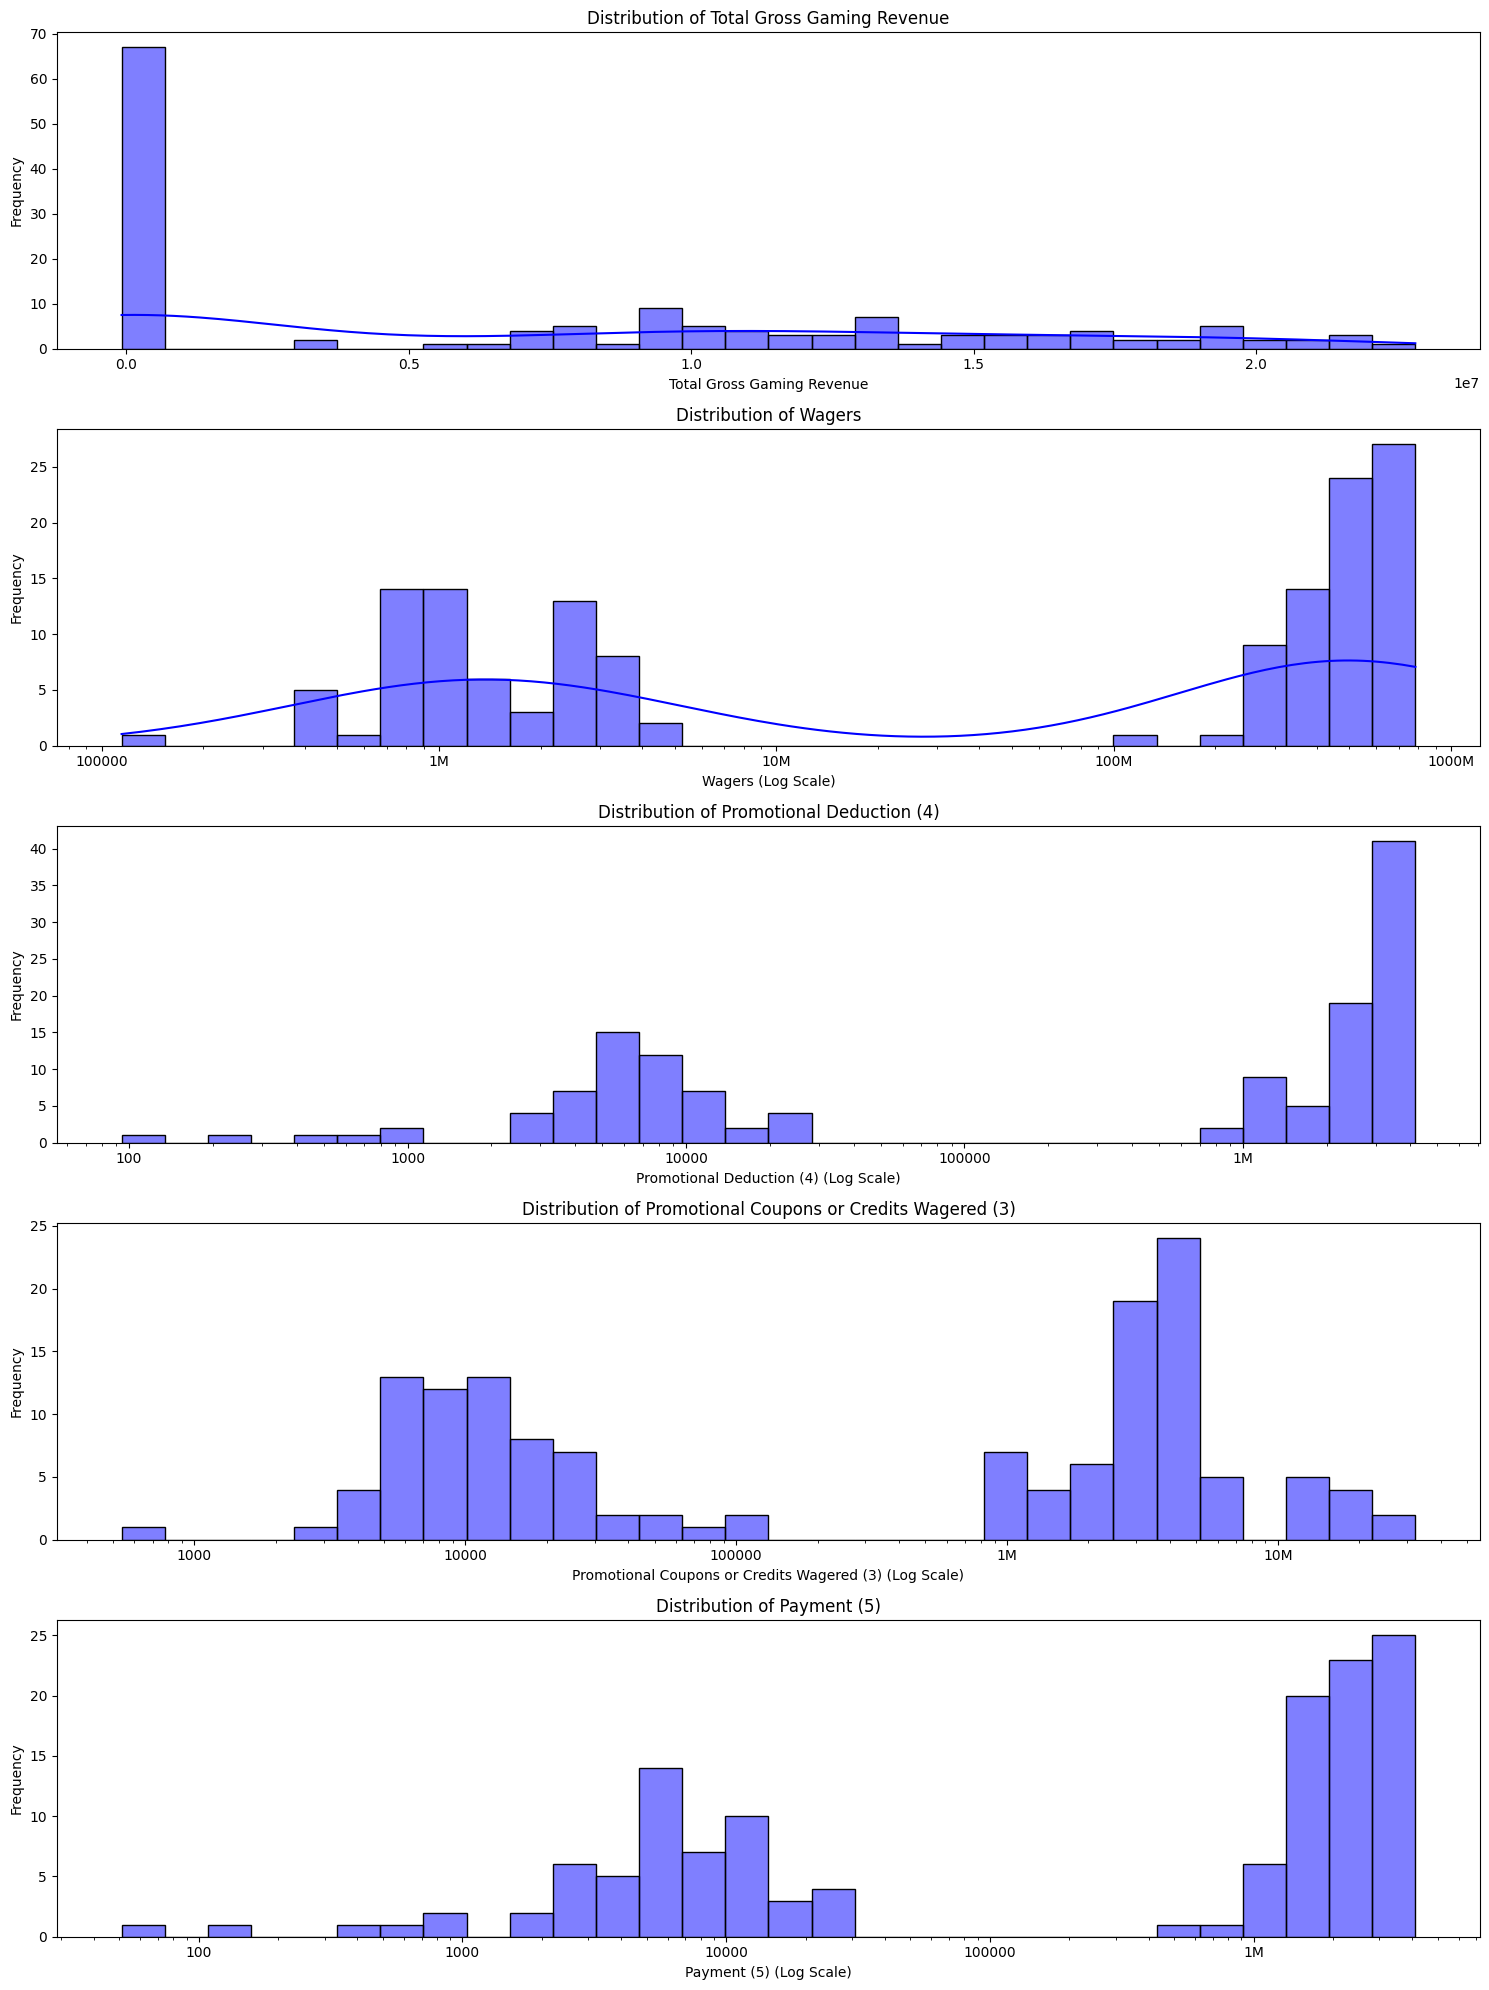

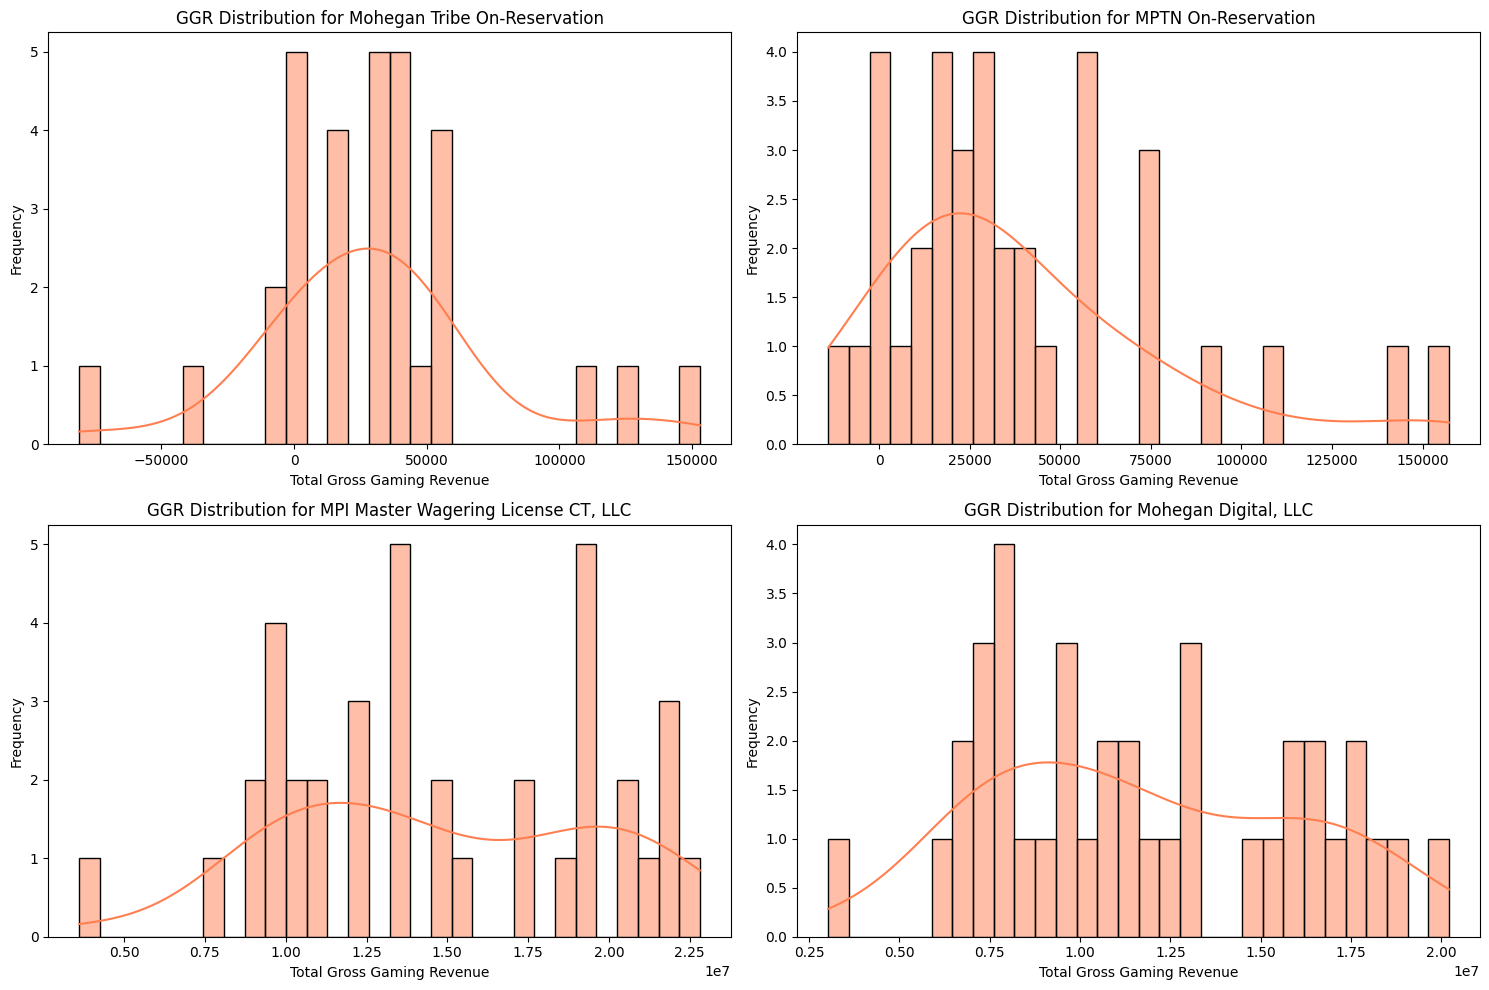

In [5]:
# Filter for unique numeric columns
numeric_columns = [
    col for col in set(key_columns) 
    if col not in ['Fiscal Year', 'Month Ending', 'Licensee'] 
    and pd.api.types.is_numeric_dtype(df[col])
]

# Plot histograms for overall distribution of each numeric revenue metric
plt.figure(figsize=(15, len(numeric_columns) * 4))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns), 1, i)
    # Use log scale for x-axis if data spans multiple orders of magnitude
    if df[col].max() / (df[col].min() + 1e-10) > 1000:  # Avoid division by zero
        sns.histplot(df[col], bins=30, kde=True, log_scale=True, color='blue')
        plt.xlabel(f'{col} (Log Scale)')
        # Format x-axis for large values (e.g., millions)
        plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))
    else:
        sns.histplot(df[col], bins=30, kde=True, color='blue')
        plt.xlabel(col)
    plt.title(f'Distribution of {col}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot histograms by Licensee for Total Gross Gaming Revenue, excluding NaN Licensees
# Filter out rows where Licensee is NaN
df_valid_licensees = df[df['Licensee'].notna()]

# Get unique licensees (excluding NaN)
licensees = df_valid_licensees['Licensee'].unique()
num_licensees = len(licensees)
rows = (num_licensees + 1) // 2  # Dynamic rows for subplot grid (2 columns)

# Plot only if there are valid licensees
if num_licensees > 0:
    plt.figure(figsize=(15, rows * 5))  # Adjust height based on number of rows
    for i, licensee in enumerate(licensees, 1):
        plt.subplot(rows, 2, i)
        licensee_data = df_valid_licensees[df_valid_licensees['Licensee'] == licensee]['Total Gross Gaming Revenue']
        if licensee_data.max() / (licensee_data.min() + 1e-10) > 1000:
            sns.histplot(licensee_data, bins=30, kde=True, log_scale=True, color='coral')
            plt.xlabel('Total Gross Gaming Revenue (Log Scale)')
            plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))
        else:
            sns.histplot(licensee_data, bins=30, kde=True, color='coral')
            plt.xlabel('Total Gross Gaming Revenue')
        plt.title(f'GGR Distribution for {licensee}')
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

#### Plotting line chart to visualize revenue trends over time

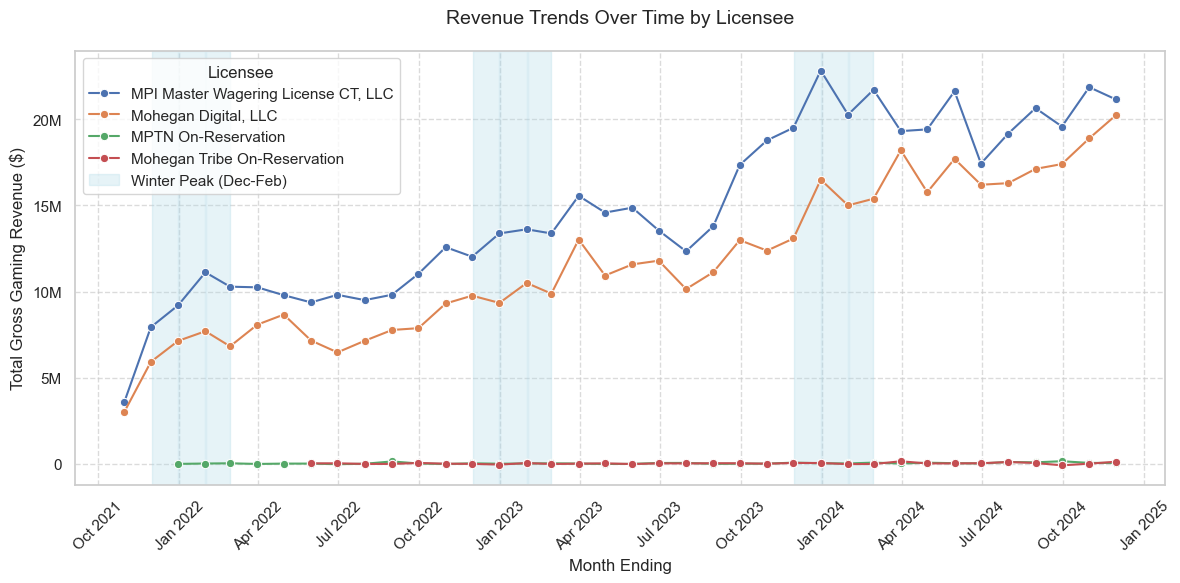

In [ ]:
# Grouping by 'Month Ending' and 'Licensee' to calculate total GGR for each licensee over time
ggr_trends = df.groupby(['Month Ending', 'Licensee'])['Total Gross Gaming Revenue'].sum().reset_index()

# Creating the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=ggr_trends, x='Month Ending', y='Total Gross Gaming Revenue', hue='Licensee', marker='o')

# Customizing the plot
plt.title('Revenue Trends Over Time by Licensee', fontsize=14, pad=20)
plt.xlabel('Month Ending', fontsize=12)
plt.ylabel('Total Gross Gaming Revenue ($)', fontsize=12)

# Format the x-axis to show dates in slanting format
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every 3rd month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Month Year'
plt.xticks(rotation=45)

# Format the y-axis for large values (e.g., millions)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))

# Highlighting seasonal peaks (Dec-Feb)
winter_months = [(12, 1, 2)]  # December, January, February
years = ggr_trends['Month Ending'].dt.year.unique()  # Get unique years in the dataset

# Add shaded regions for winter periods (Dec-Feb)
for year in years:
    for month in [12, 1, 2]:
        # For December, shade the entire month
        if month == 12:
            start_date = pd.Timestamp(year=year, month=month, day=1)
            end_date = pd.Timestamp(year=year, month=month, day=31)
        else:
            # For January and February, shade the entire month in the next year
            start_date = pd.Timestamp(year=year if month != 12 else year + 1, month=month, day=1)
            end_date = pd.Timestamp(year=year if month != 12 else year + 1, month=month, day=28 if month == 2 else 31)
        
        # Only shade if the date range is within the dataset's range
        if start_date >= ggr_trends['Month Ending'].min() and end_date <= ggr_trends['Month Ending'].max():
            plt.axvspan(start_date, end_date, color='lightblue', alpha=0.3, label='Winter Peak (Dec-Feb)' if year == years[0] and month == 12 else "")

# Add annotations for clarity
plt.legend(title='Licensee', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Step 6: Save the plot for inclusion in the PowerPoint
plt.savefig('ggr_trends_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

#### Scatter plot or bar chart comparing Promotional Deduction vs. Total Gross Gaming Revenue across Deduction Period (Pre/Post-Oct 2023).

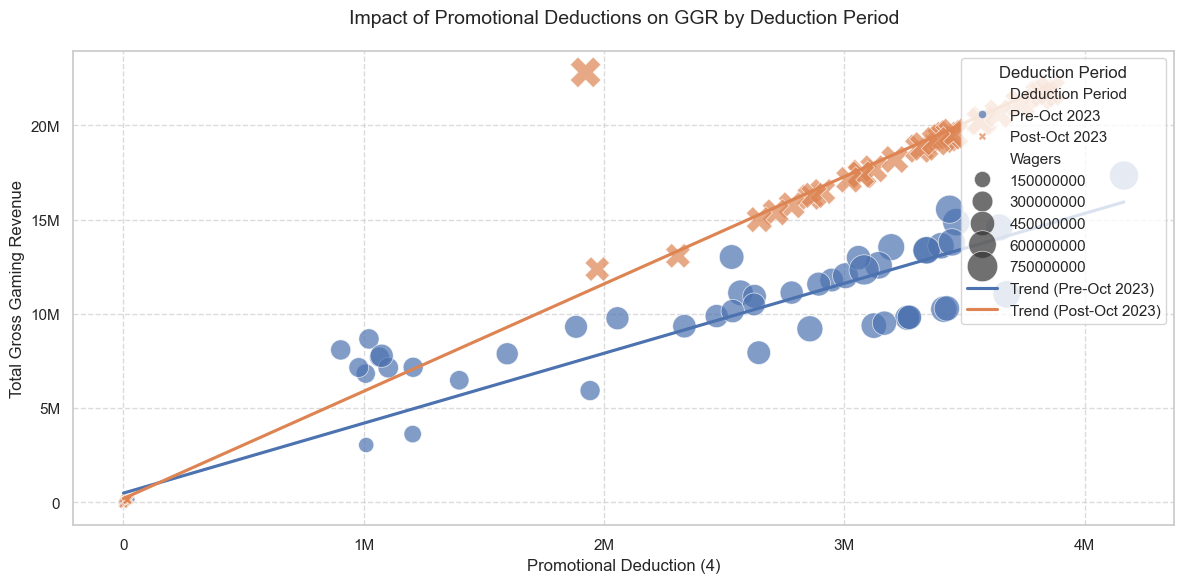

In [ ]:

# Categorize as Pre-Oct 2023 or Post-Oct 2023 based on the regulatory change
df['Deduction Period'] = df['Month Ending'].apply(
    lambda x: 'Pre-Oct 2023' if x < pd.Timestamp('2023-10-01') else 'Post-Oct 2023'
)

# Creating the scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Promotional Deduction (4)',
    y='Total Gross Gaming Revenue',
    hue='Deduction Period',
    style='Deduction Period',
    size='Wagers',  # Use Wagers to scale the size of points
    sizes=(50, 500),  # Range of point sizes
    alpha=0.7
)

# Customizing the plot
plt.title('Impact of Promotional Deductions on GGR by Deduction Period', fontsize=14, pad=20)
plt.xlabel('Promotional Deduction ($)', fontsize=12)
plt.ylabel('Total Gross Gaming Revenue ($)', fontsize=12)

# Format the x-axis and y-axis for large values (e.g., millions)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))

# Add a trend line for each period to show the relationship
# Fit a linear regression line for each Deduction Period
for period in df['Deduction Period'].unique():
    subset = df[df['Deduction Period'] == period]
    sns.regplot(
        data=subset,
        x='Promotional Deduction (4)',
        y='Total Gross Gaming Revenue',
        scatter=False,  # Don't replot the points
        label=f'Trend ({period})',
        ci=None  # No confidence interval for clarity
    )
plt.legend(title='Deduction Period', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Saving the plot
plt.savefig('promotional_impact_on_ggr.png', dpi=300, bbox_inches='tight')
plt.show()

####  Bar graph to visualize the impact of promotional deductions on GGR pre 2023 and post 2023

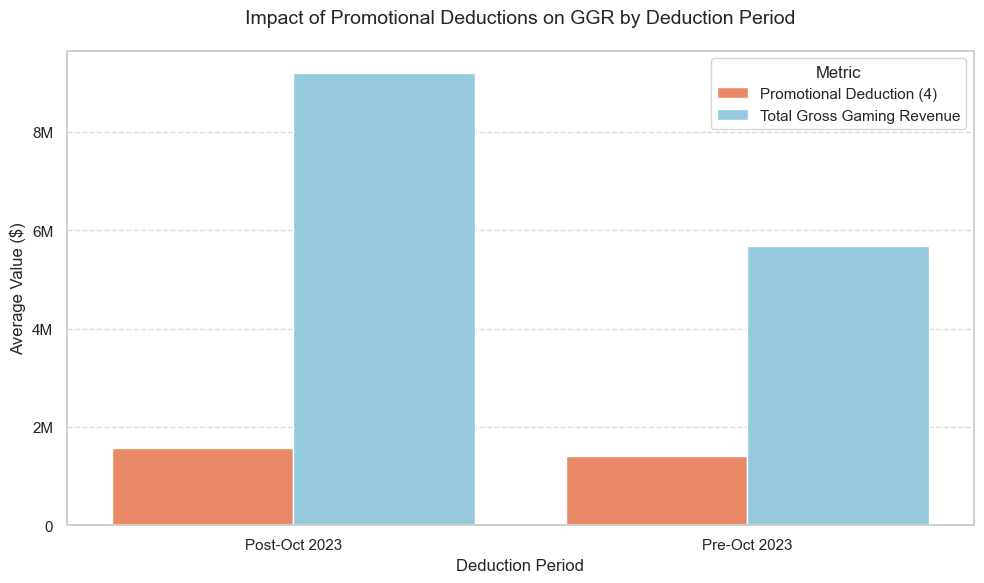

In [ ]:

# Categorize as Pre-Oct 2023 or Post-Oct 2023 based on the regulatory change
df['Deduction Period'] = df['Month Ending'].apply(
    lambda x: 'Pre-Oct 2023' if x < pd.Timestamp('2023-10-01') else 'Post-Oct 2023'
)

# Aggregating data by Deduction Period
# Calculating the mean Promotional Deduction and Total Gross Gaming Revenue for each period
agg_data = df.groupby('Deduction Period').agg({
    'Promotional Deduction (4)': 'mean',
    'Total Gross Gaming Revenue': 'mean'
}).reset_index()

# Melting the data for easier plotting with seaborn
# Converting the aggregated data into a long format for a grouped bar chart
melted_data = agg_data.melt(id_vars='Deduction Period', 
                            value_vars=['Promotional Deduction (4)', 'Total Gross Gaming Revenue'],
                            var_name='Metric', value_name='Value')

# Creating the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_data, 
            x='Deduction Period', 
            y='Value', 
            hue='Metric',
            palette={'Promotional Deduction (4)': 'coral', 'Total Gross Gaming Revenue': 'skyblue'})

# Customizing the plot
plt.title('Impact of Promotional Deductions on GGR by Deduction Period', fontsize=14, pad=20)
plt.xlabel('Deduction Period', fontsize=12)
plt.ylabel('Average Value ($)', fontsize=12)

# Formatting the y-axis for large values (e.g., millions)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))

plt.legend(title='Metric', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()

# Save the plot for inclusion in the PowerPoint
plt.savefig('promotional_impact_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

#### Licensee Performance Comparison by months

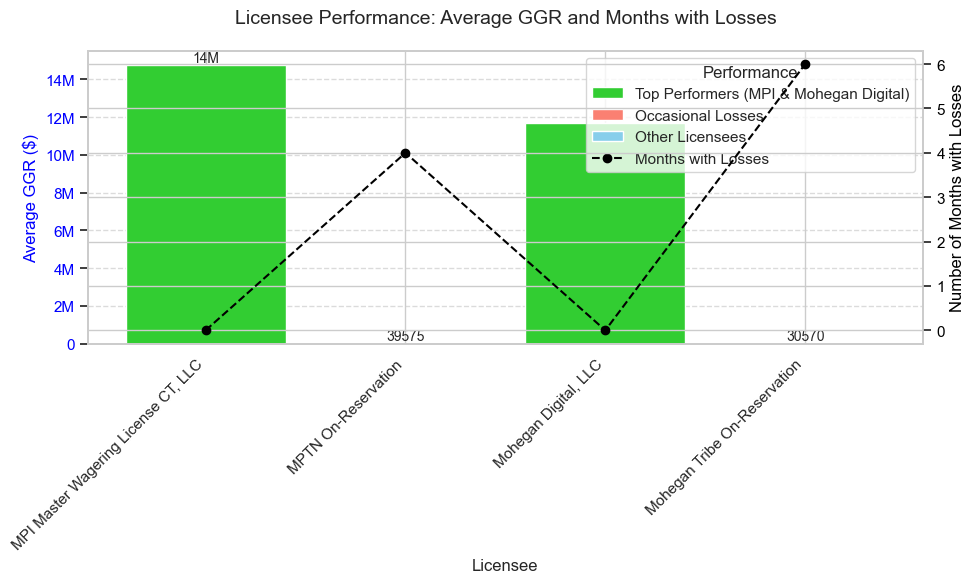

In [ ]:
# Calculate the average GGR by Licensee
avg_ggr = df.groupby('Licensee')['Total Gross Gaming Revenue'].mean().reset_index()

# Calculate the number of months with losses (negative Win/(Loss)) for each Licensee
losses_count = df[df['Online Casino Gaming Win/(Loss)'] < 0].groupby('Licensee').size().reset_index(name='Months with Losses')
# Merge with avg_ggr to ensure all licensees are included (fill with 0 for those with no losses)
avg_ggr = avg_ggr.merge(losses_count, on='Licensee', how='left').fillna(0)

# Identify licensees with occasional losses and top performers
licensees_with_losses = avg_ggr[avg_ggr['Months with Losses'] > 0]['Licensee'].unique()
top_performers = ['MPI Master Wagering License CT, LLC', 'Mohegan Digital, LLC']

# Create a color palette to highlight top performers, those with losses, and others
colors = ['skyblue'] * len(avg_ggr)  # Default color for other licensees
for i, licensee in enumerate(avg_ggr['Licensee']):
    if licensee in top_performers:
        colors[i] = 'limegreen'  # Highlight top performers in green
    elif licensee in licensees_with_losses:
        colors[i] = 'salmon'  # Highlight those with losses in red

# Create the figure and primary axis for the bar chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the bar chart for average GGR on the primary y-axis
bars = ax1.bar(avg_ggr['Licensee'], avg_ggr['Total Gross Gaming Revenue'], color=colors)

# Customize the primary y-axis (GGR)
ax1.set_title('Licensee Performance: Average GGR and Months with Losses', fontsize=14, pad=20)
ax1.set_xlabel('Licensee', fontsize=12)
ax1.set_ylabel('Average GGR ($)', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Rotate x-axis labels for better readability
ax1.set_xticks(range(len(avg_ggr['Licensee'])))
ax1.set_xticklabels(avg_ggr['Licensee'], rotation=45, ha='right')

# Format the y-axis for large values (e.g., millions)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))

# Add labels above each bar to show the exact average GGR value
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, 
        height, 
        f'{int(height/1e6)}M' if height >= 1e6 else f'{int(height)}',
        ha='center', 
        va='bottom', 
        fontsize=10
    )
# Create a secondary y-axis for the number of months with losses
ax2 = ax1.twinx()
ax2.plot(
    avg_ggr['Licensee'],
    avg_ggr['Months with Losses'],
    color='black',
    marker='o',
    linestyle='--',
    label='Months with Losses'
)
# Customize the secondary y-axis (Months with Losses)
ax2.set_ylabel('Number of Months with Losses', fontsize=12, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add a legend to explain the colors and the line
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='limegreen', label='Top Performers (MPI & Mohegan Digital)'),
    Patch(facecolor='salmon', label='Occasional Losses'),
    Patch(facecolor='skyblue', label='Other Licensees')
]
# Combine legends from both axes
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(legend_elements + lines2, [element.get_label() for element in legend_elements] + labels2, 
           loc='upper right', title='Performance')

# Final touches
ax1.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()

# Saving the plot
plt.savefig('licensee_performance_ggr_with_losses.png', dpi=300, bbox_inches='tight')
plt.show()

#### Licensee Performance Comparison by percentage

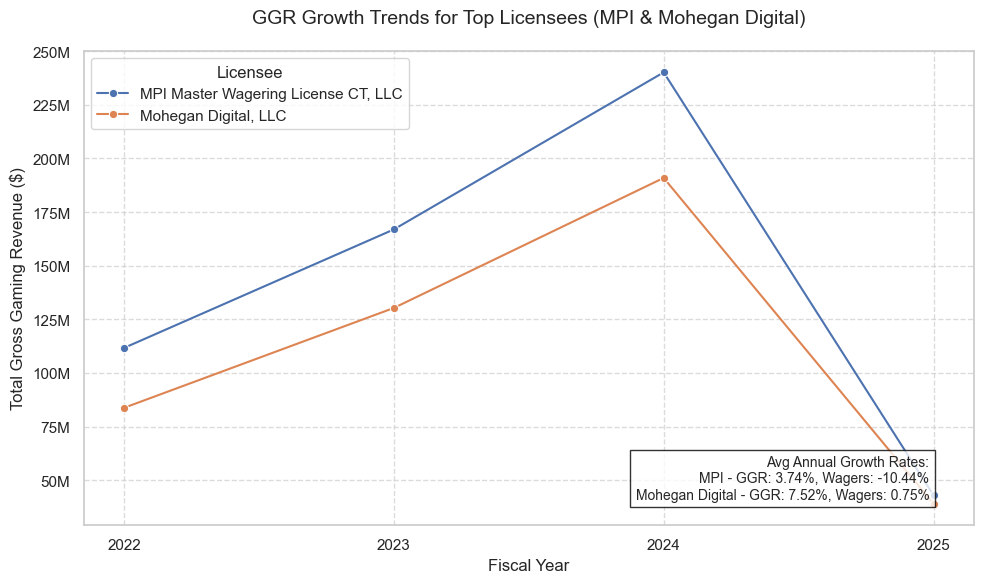

In [ ]:

# Filter data for top licensees (MPI and Mohegan Digital)
top_licensees = ['MPI Master Wagering License CT, LLC', 'Mohegan Digital, LLC']
df_top = df[df['Licensee'].isin(top_licensees)].copy()

# Ensure Fiscal Year is available (if not already in the dataset, derive it)
# Fiscal Year in your dataset runs from Oct to Sep (e.g., Oct 2021 to Sep 2022 is FY 2022)
df_top['Fiscal Year'] = df_top['Month Ending'].apply(
    lambda x: x.year if x.month < 10 else x.year + 1
)

# Aggregate GGR by Licensee and Fiscal Year
ggr_trends = df_top.groupby(['Licensee', 'Fiscal Year'])['Total Gross Gaming Revenue'].sum().reset_index()

# Calculate average annual growth rates for GGR and Wagers
# Function to calculate average annual growth rate
def calculate_growth_rate(data, metric):
    yearly_values = data.groupby('Fiscal Year')[metric].sum()
    growth_rates = yearly_values.pct_change().dropna() * 100  # Convert to percentage
    return growth_rates.mean()

# Calculate growth rates for GGR and Wagers for each licensee
growth_rates = {}
for licensee in top_licensees:
    licensee_data = df_top[df_top['Licensee'] == licensee]
    ggr_growth = calculate_growth_rate(licensee_data, 'Total Gross Gaming Revenue')
    wagers_growth = calculate_growth_rate(licensee_data, 'Wagers')
    growth_rates[licensee] = {'GGR Growth': ggr_growth, 'Wagers Growth': wagers_growth}

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=ggr_trends, x='Fiscal Year', y='Total Gross Gaming Revenue', hue='Licensee', marker='o')

# Customize the plot
plt.title('GGR Growth Trends for Top Licensees (MPI & Mohegan Digital)', fontsize=14, pad=20)
plt.xlabel('Fiscal Year', fontsize=12)
plt.ylabel('Total Gross Gaming Revenue ($)', fontsize=12)

# Format the y-axis for large values (e.g., millions)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x)}'))

# Set x-axis ticks to show only integer fiscal years
plt.gca().set_xticks(ggr_trends['Fiscal Year'].unique())

# Add annotations for growth rates
# Create a text box to display the average annual growth rates
annotation_text = (
    f"Avg Annual Growth Rates:\n"
    f"MPI - GGR: {growth_rates['MPI Master Wagering License CT, LLC']['GGR Growth']:.2f}%, "
    f"Wagers: {growth_rates['MPI Master Wagering License CT, LLC']['Wagers Growth']:.2f}%\n"
    f"Mohegan Digital - GGR: {growth_rates['Mohegan Digital, LLC']['GGR Growth']:.2f}%, "
    f"Wagers: {growth_rates['Mohegan Digital, LLC']['Wagers Growth']:.2f}%"
)
plt.gca().text(
    0.95, 0.05, annotation_text,
    transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='bottom', horizontalalignment='right',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
)

# Step 8: Final touches
plt.legend(title='Licensee', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Step 9: Save the plot for inclusion in the PowerPoint
plt.savefig('ggr_growth_top_licensees.png', dpi=300, bbox_inches='tight')
plt.show()

#### Year-over-Year GGR Growth by Licensee(Fiscal Years 2021/22 to 2024/25)

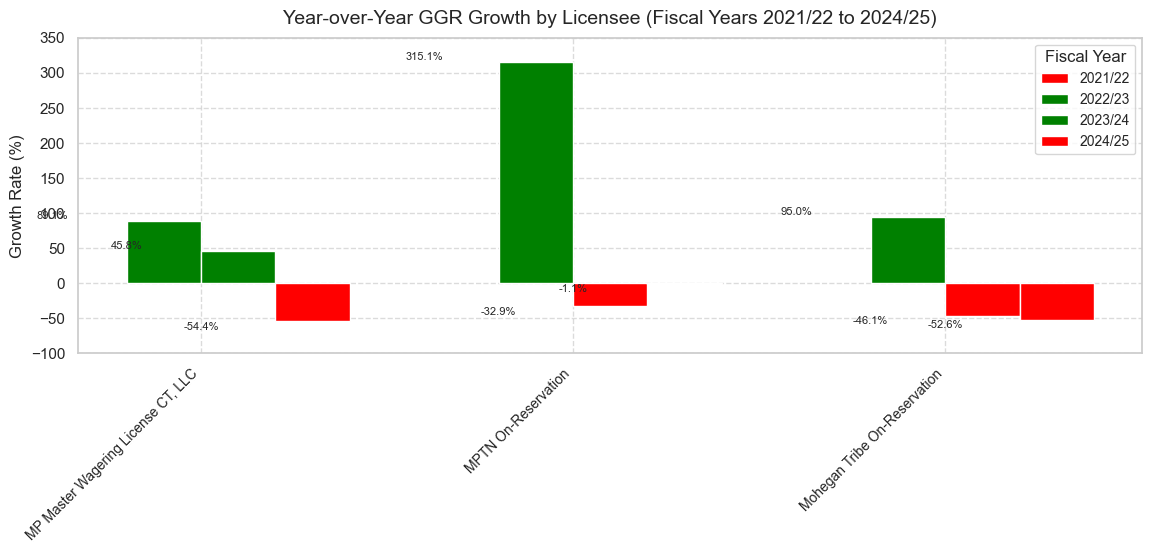

In [32]:

licensees = ['MP Master Wagering License CT, LLC', 'MPTN On-Reservation', 'Mohegan Tribe On-Reservation']
years = ['2021/22', '2022/23', '2023/24', '2024/25']
growth_rates = [[np.nan, 89.08, 45.80, -54.35], 
                [np.nan, 315.12, -32.86, -1.05], 
                [np.nan, 94.95, -46.15, -52.65]]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(licensees))
width = 0.2

for i, year in enumerate(years):
    rates = [growth_rates[j][i] for j in range(len(licensees))]
    ax.bar([p + i * width for p in x], rates, width, label=year,
           color=['green' if not np.isnan(r) and r > 0 else 'red' for r in rates])

for i, licensee_rates in enumerate(growth_rates):
    for j, v in enumerate(licensee_rates):
        if not np.isnan(v):
            ax.text(i + j * width - 0.3, v, f'{v:.1f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=8)

ax.set_ylabel('Growth Rate (%)', fontsize=12)
ax.set_title('Year-over-Year GGR Growth by Licensee (Fiscal Years 2021/22 to 2024/25)', fontsize=14, pad=10)
ax.set_ylim(-100, 350)
ax.set_xticks([p + 1.5 * width for p in x])
ax.set_xticklabels(licensees, rotation=45, ha='right', fontsize=10)
ax.legend(title='Fiscal Year', title_fontsize=12, fontsize=10)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(pad=2.0)
plt.show()

#### Average return on investment visualization on promotional spending by licensee


Average Promotional ROI by Licensee:
                              Licensee  Promo ROI
0  MPI Master Wagering License CT, LLC   3.354843
1                  MPTN On-Reservation   2.931480
2                 Mohegan Digital, LLC   4.655583
3         Mohegan Tribe On-Reservation   3.769415


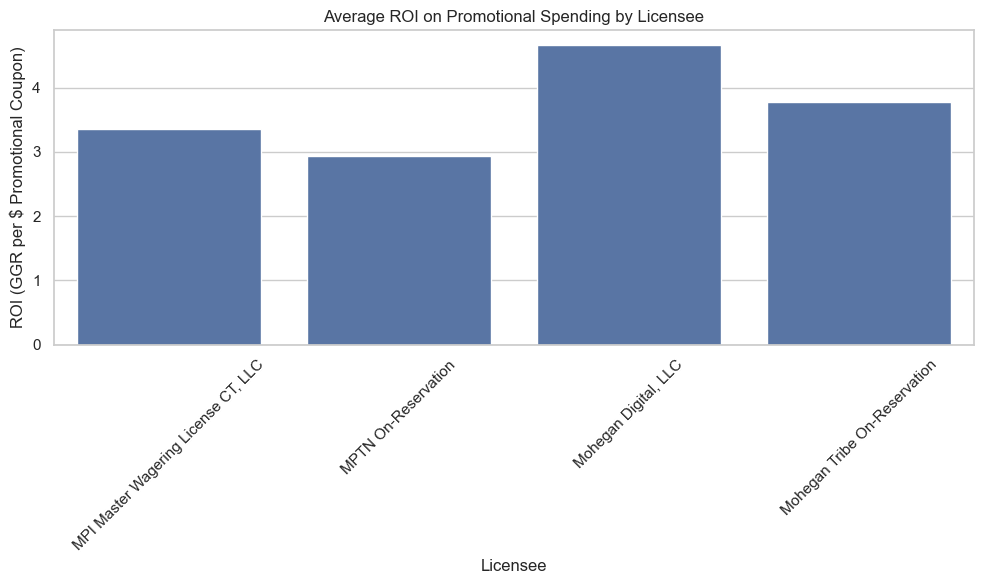

In [36]:
# How does the return on promotional investment (ROI) vary across licensees, considering Promotional Coupons Wagered versus the resulting increase in Wagers and GGR?
# Calculating ROI on Promotional Investment
df['Promo ROI'] = (df['Total Gross Gaming Revenue'] / df['Promotional Coupons or Credits Wagered (3)']).replace([float('inf'), -float('inf')], 0)
promo_roi_summary = df.groupby('Licensee')['Promo ROI'].mean().reset_index()
print("\nAverage Promotional ROI by Licensee:")
print(promo_roi_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=promo_roi_summary, x='Licensee', y='Promo ROI')
plt.title('Average ROI on Promotional Spending by Licensee')
plt.xlabel('Licensee')
plt.ylabel('ROI (GGR per $ Promotional Coupon)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Analysis
Examine relationships between variables to uncover dependencies.

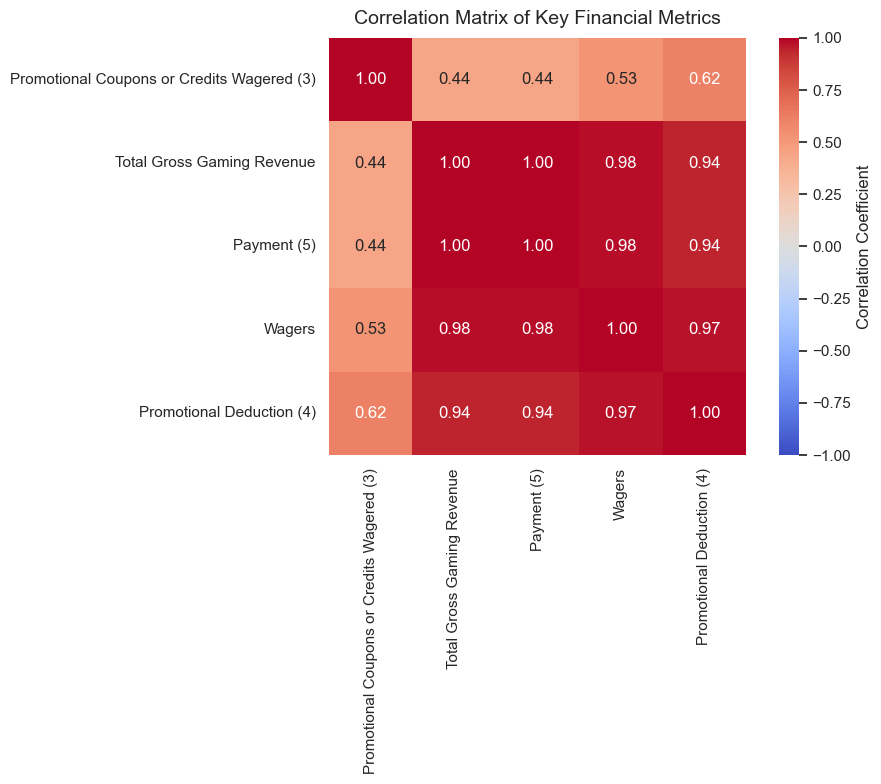


Insights from Correlation Analysis:
-----------------------------------
- Promotional Coupons or Credits Wagered (3) vs. Total Gross Gaming Revenue: moderate positive correlation (r = 0.44)
- Promotional Coupons or Credits Wagered (3) vs. Payment (5): moderate positive correlation (r = 0.44)
- Promotional Coupons or Credits Wagered (3) vs. Wagers: moderate positive correlation (r = 0.53)
- Promotional Coupons or Credits Wagered (3) vs. Promotional Deduction (4): moderate positive correlation (r = 0.62)
- Total Gross Gaming Revenue vs. Payment (5): strong positive correlation (r = 1.00)
- Total Gross Gaming Revenue vs. Wagers: strong positive correlation (r = 0.98)
- Total Gross Gaming Revenue vs. Promotional Deduction (4): strong positive correlation (r = 0.94)
- Payment (5) vs. Wagers: strong positive correlation (r = 0.98)
- Payment (5) vs. Promotional Deduction (4): strong positive correlation (r = 0.94)
- Wagers vs. Promotional Deduction (4): strong positive correlation (r = 0.97)

In [28]:
# Filter for unique numeric columns
numeric_columns = [
    col for col in set(key_columns) 
    if col not in ['Fiscal Year', 'Month Ending', 'Licensee'] 
    and pd.api.types.is_numeric_dtype(df[col])
]

# Compute correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Key Financial Metrics', fontsize=14, pad=10)
plt.tight_layout()
plt.show()

# Insights based on correlation matrix
print("\nInsights from Correlation Analysis:")
print("-----------------------------------")
for i, col1 in enumerate(numeric_columns):
    for j, col2 in enumerate(numeric_columns[i+1:], i+1):
        corr = correlation_matrix.loc[col1, col2]
        strength = "strong" if abs(corr) > 0.7 else "moderate" if abs(corr) > 0.3 else "weak"
        direction = "positive" if corr > 0 else "negative"
        print(f"- {col1} vs. {col2}: {strength} {direction} correlation (r = {corr:.2f})")

In [34]:
# Which licensee achieves the highest profit margin (Payment as a percentage of GGR) after accounting for the 18% State payment rate, and what factors contribute to this?
# Calculating Profit Margin (Payment/GGR)
df['Profit Margin'] = (1 - (df['Payment (5)'] / df['Total Gross Gaming Revenue'])) * 100  # After 18% payment
df['Profit Margin'] = df['Profit Margin'].replace([float('inf'), -float('inf')], 0).fillna(0)
margin_summary = df.groupby('Licensee')['Profit Margin'].mean().reset_index()
print("\n Average Profit Margin After State Payment by Licensee (%):")
print(margin_summary)


 Average Profit Margin After State Payment by Licensee (%):
                              Licensee  Profit Margin
0  MPI Master Wagering License CT, LLC      82.000000
1                  MPTN On-Reservation      83.999936
2                 Mohegan Digital, LLC      82.000000
3         Mohegan Tribe On-Reservation      85.477161


## 5. Insights and Recommendations
### 5.1 Key Insights
- **Revenue Growth**: GGR has increased significantly since October 2021, driven by MPI and Mohegan Digital, with peaks in winter months (Dec-Feb).
- **Promotional Impact**: Higher promotional spending boosts Wagers but reduces GGR under stricter deduction caps (15% since Oct 2023).
- **Performance Disparity**: MPI and Mohegan Digital dominate GGR and Payments, while Mohegan Tribe and MPTN show occasional losses.
- **Wagering Patterns**: Cancelled wagers are minimal but correlate with lower GGR in some months, suggesting process issues.

### 5.2 Business Recommendations
1. **Optimize Promotions**: Limit promotional spending to align with the 15% deduction cap to maximize GGR, especially for MPI and Mohegan Digital.
2. **Seasonal Strategy**: Increase marketing and staffing in winter months to capitalize on seasonal peaks.
3. **Support Underperformers**: Provide operational support to Mohegan Tribe and MPTN to reduce negative Win/(Loss) occurrences (e.g., risk management training).
4. **Reduce Cancellations**: Investigate and streamline processes causing cancelled wagers to minimize revenue loss.
5. **Expand Top Performers**: Invest in scaling MPI and Mohegan Digital operations, given their consistent growth and high ROI potential.

### 5.3 Risk Factors
- **Regulatory Tightening**: Further deduction limit reductions could erode profitability.
- **Data Integrity**: Issues like the May 2024 latency error (Mohegan Digital) highlight the need for real-time validation.
- **Market Saturation**: Slowing growth rates may indicate nearing market capacity.

## 6. Conclusion
This EDA reveals a thriving online casino gaming market in Connecticut, with MPI and Mohegan Digital leading in revenue and efficiency. Promotional strategies drive engagement but require optimization under regulatory constraints. Seasonal trends and operational disparities offer opportunities for targeted improvements. These insights equip casino operators with the data needed to enhance profitability and navigate regulatory challenges effectively.